Columns: ['url', 'isMalicious']
Shape: (194798, 2)

=== Class Distribution ===
label
Benign       97399
Malicious    97399
Name: count, dtype: int64

Extracting features...
Extracted 15 features from 194798 URLs

Feature columns: ['url_length', 'num_dots', 'num_hyphens', 'num_underscores', 'num_slashes', 'num_digits', 'num_special', 'has_https', 'has_at', 'has_double_slash', 'num_subdomains', 'url_entropy', 'hostname_length', 'path_length', 'has_port']


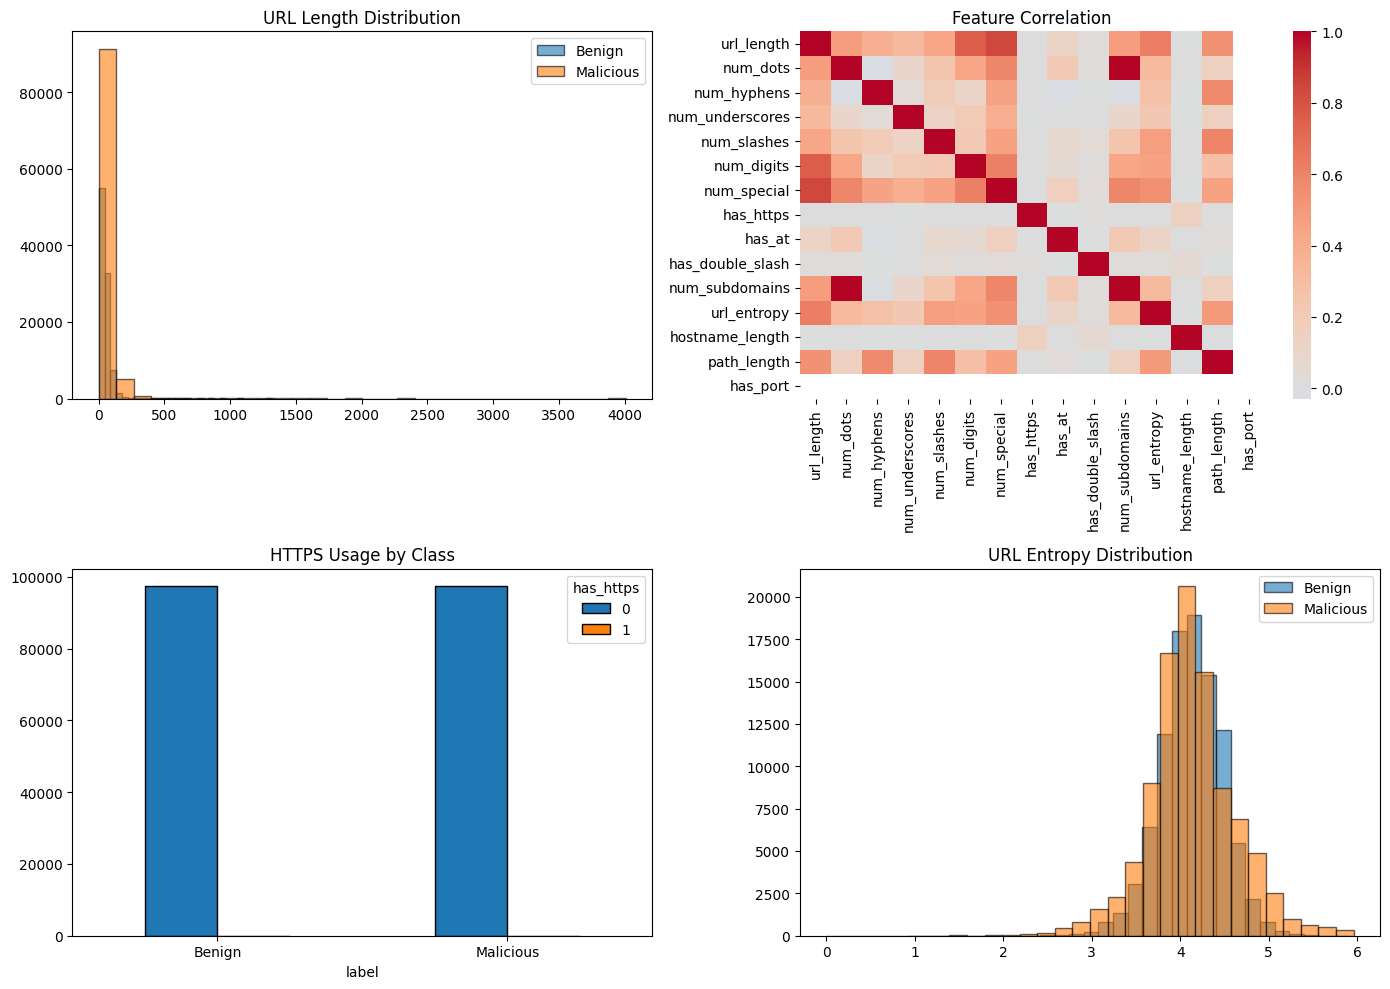


Logistic Regression — Accuracy: 0.6802
              precision    recall  f1-score   support

      Benign       0.70      0.62      0.66     29149
   Malicious       0.66      0.74      0.70     29291

    accuracy                           0.68     58440
   macro avg       0.68      0.68      0.68     58440
weighted avg       0.68      0.68      0.68     58440


Random Forest — Accuracy: 0.8352
              precision    recall  f1-score   support

      Benign       0.84      0.82      0.83     29149
   Malicious       0.83      0.85      0.84     29291

    accuracy                           0.84     58440
   macro avg       0.84      0.84      0.84     58440
weighted avg       0.84      0.84      0.84     58440


Gradient Boosting — Accuracy: 0.7867
              precision    recall  f1-score   support

      Benign       0.80      0.76      0.78     29149
   Malicious       0.78      0.81      0.79     29291

    accuracy                           0.79     58440
   macro avg    

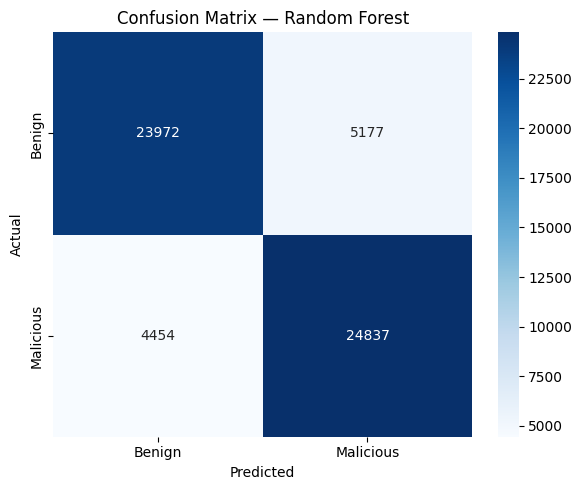


=== Predictions on New URLs ===
  [SAFE] https://www.google.com/search?q=python
  [SAFE] http://free-iphone-winner.xyz/claim@now//download
  [SAFE] https://github.com/user/repository
  [MALICIOUS] http://192.168.0.1:8080/admin/shell.php
  [SAFE] https://www.wikipedia.org/wiki/Machine_learning


In [1]:
# Experiment 7: Malicious URL Detection using Machine Learning

import pandas as pd
import numpy as np
from urllib.parse import urlparse
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_curve, auc)

# 1. Load Dataset
url = "https://raw.githubusercontent.com/incertum/cyber-matrix-ai/master/Malicious-URL-Detection-Deep-Learning/data/url_data_mega_deep_learning.csv"

try:
    df = pd.read_csv(url)
except:
    # Fallback: generate sample dataset
    print("Generating sample URL dataset...")
    benign = [
        "https://www.google.com", "https://www.github.com/repo",
        "https://stackoverflow.com/questions", "https://www.amazon.com/products",
        "https://en.wikipedia.org/wiki/Python", "https://www.youtube.com/watch",
        "https://docs.python.org/3/library", "https://www.linkedin.com/in/user",
        "https://medium.com/article-title", "https://www.reddit.com/r/python"
    ] * 50
    malicious = [
        "http://free-iphone.xyz/claim-now", "http://192.168.1.1/admin/login.php",
        "http://paypa1-secure.com/update@info", "http://bit.ly/3xYz-malware",
        "http://download-free.tk/crack//setup.exe", "http://banking-update.ml/verify",
        "http://0x42.0x66.0x0b.0x63/exploit", "http://amaz0n-login.cc/secure",
        "http://free-money.gq/click-here---now", "http://192.168.0.1:8080/shell.php"
    ] * 50
    df = pd.DataFrame({
        'url': benign + malicious,
        'label': [0]*len(benign) + [1]*len(malicious)
    })

# Check columns
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

# Standardize column names
if 'isMalicious' in df.columns:
    df = df.rename(columns={'isMalicious': 'label'})
if 'URL' in df.columns:
    df = df.rename(columns={'URL': 'url'})

# Keep only url and label
url_col = [c for c in df.columns if 'url' in c.lower()][0]
label_col = [c for c in df.columns if 'label' in c.lower() or 'malicious' in c.lower() or 'class' in c.lower() or 'type' in c.lower()][0]
df = df[[url_col, label_col]].dropna()
df.columns = ['url', 'label']
df['label'] = df['label'].astype(int)

print(f"\n=== Class Distribution ===")
print(df['label'].value_counts().rename({0: 'Benign', 1: 'Malicious'}))

# 2. Feature Extraction from URLs
def extract_features(url_string):
    features = {}
    features['url_length'] = len(url_string)
    features['num_dots'] = url_string.count('.')
    features['num_hyphens'] = url_string.count('-')
    features['num_underscores'] = url_string.count('_')
    features['num_slashes'] = url_string.count('/')
    features['num_digits'] = sum(c.isdigit() for c in url_string)
    features['num_special'] = len(re.findall(r'[^a-zA-Z0-9]', url_string))
    features['has_https'] = 1 if url_string.startswith('https') else 0
    features['has_at'] = 1 if '@' in url_string else 0
    features['has_double_slash'] = 1 if '//' in url_string[8:] else 0
    features['num_subdomains'] = url_string.count('.') - 1
    features['url_entropy'] = 0

    # Shannon entropy
    from collections import Counter
    counts = Counter(url_string)
    length = len(url_string)
    if length > 0:
        features['url_entropy'] = -sum((c/length) * np.log2(c/length) for c in counts.values())

    try:
        parsed = urlparse(url_string)
        features['hostname_length'] = len(parsed.hostname) if parsed.hostname else 0
        features['path_length'] = len(parsed.path)
        features['has_port'] = 1 if parsed.port else 0
    except:
        features['hostname_length'] = 0
        features['path_length'] = 0
        features['has_port'] = 0

    return features

print("\nExtracting features...")
feature_df = pd.DataFrame([extract_features(u) for u in df['url']])
print(f"Extracted {feature_df.shape[1]} features from {feature_df.shape[0]} URLs")
print("\nFeature columns:", feature_df.columns.tolist())

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# URL length distribution by class
for label, name in [(0, 'Benign'), (1, 'Malicious')]:
    axes[0,0].hist(feature_df.loc[df['label']==label, 'url_length'],
                   bins=30, alpha=0.6, label=name, edgecolor='black')
axes[0,0].set_title("URL Length Distribution")
axes[0,0].legend()

# Feature correlation
sns.heatmap(feature_df.corr(), ax=axes[0,1], cmap='coolwarm', center=0)
axes[0,1].set_title("Feature Correlation")

# HTTPS usage
pd.crosstab(df['label'], feature_df['has_https']).plot(kind='bar', ax=axes[1,0], edgecolor='black')
axes[1,0].set_title("HTTPS Usage by Class")
axes[1,0].set_xticklabels(['Benign', 'Malicious'], rotation=0)

# Entropy distribution
for label, name in [(0, 'Benign'), (1, 'Malicious')]:
    axes[1,1].hist(feature_df.loc[df['label']==label, 'url_entropy'],
                   bins=30, alpha=0.6, label=name, edgecolor='black')
axes[1,1].set_title("URL Entropy Distribution")
axes[1,1].legend()

plt.tight_layout()
plt.show()

# 4. Model Training
X = feature_df
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})
    print(f"\n{'='*50}")
    print(f"{name} — Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

# 5. Results Comparison
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

# Best model confusion matrix
best_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_model = models[best_name]
y_pred = best_model.predict(X_test_sc)

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malicious'], yticklabels=['Benign','Malicious'])
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 6. Predict on New URLs
new_urls = [
    "https://www.google.com/search?q=python",
    "http://free-iphone-winner.xyz/claim@now//download",
    "https://github.com/user/repository",
    "http://192.168.0.1:8080/admin/shell.php",
    "https://www.wikipedia.org/wiki/Machine_learning"
]

print("\n=== Predictions on New URLs ===")
new_features = pd.DataFrame([extract_features(u) for u in new_urls])
new_scaled = scaler.transform(new_features)
predictions = best_model.predict(new_scaled)

for url, pred in zip(new_urls, predictions):
    status = "MALICIOUS" if pred == 1 else "SAFE"
    print(f"  [{status}] {url}")